In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import time
import matplotlib.pyplot as plt
from collections import deque


In [12]:
ALPHA = 0.1
N_RUNS = 10
EVAL_BUDGET = 4500          # تعداد ارزیابی ثابت برای همه الگوریتم‌ها
N_FEATURES = 30
RANDOM_SEED_BASE = 42

In [13]:
# لود و پیش‌پردازش داده
url = "/home/ali/Semnan_Uni/SoftComputing/project/breast+cancer+wisconsin+diagnostic/wdbc.data"
names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(1, 31)]
df = pd.read_csv(url, header=None, names=names)

# 30 ویژگی
X = df.iloc[:, 2:].values
y = (df['diagnosis'] == 'M').astype(int) # m=1,b=0

# نرمال سازی
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [14]:
# 5. تابع ارزیابی (بدون نویز)
# def evaluate_features(mask, X=X_scaled, y=y, alpha=0.1):
#     selected = X[:, mask.astype(bool)]
#     if selected.shape[1] == 0:
#         return 0.0  # جریمه سنگین برای انتخاب صفر ویژگی
    
#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#     scores = cross_val_score(model, selected, y, cv=cv, scoring='accuracy')
#     acc = scores.mean()
#     num_features = selected.shape[1]
#     total_features = X.shape[1]
    
#     fitness = acc - alpha * (num_features / total_features)
#     return fitness

In [15]:
# با نویز
def evaluate_features(mask, X=X_scaled, y=y, noise_std=0.0):
    X_noisy = X.copy()
    if noise_std > 0:
        noise = np.random.normal(0, noise_std, X.shape)
        X_noisy += noise
    
    selected = X_noisy[:, mask.astype(bool)]
    if selected.shape[1] == 0:
        return -1.0
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(model, selected, y, cv=cv, scoring='accuracy').mean()
    
    return acc - ALPHA * (selected.shape[1] / N_FEATURES)

In [16]:

print("تعداد نمونه‌ها:", X.shape[0])
print("تعداد ویژگی‌ها:", X.shape[1])

تعداد نمونه‌ها: 569
تعداد ویژگی‌ها: 30


In [17]:
# تست چند حالت
print("\nتست objective function:")

# همه ویژگی‌ها
mask_all = np.ones(30)
score_all = evaluate_features(mask_all)
print(f"همه ویژگی‌ها → fitness: {score_all:.4f}")

# هیچ ویژگی
mask_none = np.zeros(30)
score_none = evaluate_features(mask_none)
print(f"هیچ ویژگی → fitness: {score_none:.4f}")

# فقط ۵ ویژگی اول
mask_few = np.zeros(30)
mask_few[:5] = 1
score_few = evaluate_features(mask_few)
print(f"۵ ویژگی اول → fitness: {score_few:.4f}")

# نیمی از ویژگی‌ها (تصادفی)
np.random.seed(42)
mask_half = np.random.choice([0, 1], size=30, p=[0.5, 0.5])
score_half = evaluate_features(mask_half)
print(f"تقریباً نصف ویژگی‌ها → fitness: {score_half:.4f}  (تعداد انتخابی: {mask_half.sum()})")


تست objective function:
همه ویژگی‌ها → fitness: 0.8754
هیچ ویژگی → fitness: -1.0000
۵ ویژگی اول → fitness: 0.9130
تقریباً نصف ویژگی‌ها → fitness: 0.9216  (تعداد انتخابی: 13)


In [18]:
# تست با نویز
print("\nبا نویز 0.1:")
score_all_noisy = evaluate_features(mask_all, noise_std=0.1)
print(f"همه ویژگی‌ها + نویز → {score_all_noisy:.4f}")

score_few_noisy = evaluate_features(mask_few, noise_std=0.1)
print(f"۵ ویژگی اول + نویز → {score_few_noisy:.4f}")


با نویز 0.1:
همه ویژگی‌ها + نویز → 0.8684
۵ ویژگی اول + نویز → 0.9060


In [19]:
def ga_feature_selection(n_features=30, seed=None, noise_std=0.0):
    if seed is not None:
        np.random.seed(seed)
    
    POP_SIZE = 45
    N_GENERATIONS = 100     # ۴۵۰۰ ارزیابی
    
    population = np.random.randint(0, 2, (POP_SIZE, n_features))
    
    # ارزیابی اولیه
    fitness = np.array([evaluate_features(ind, noise_std=noise_std) for ind in population])
    
    best_idx = np.argmax(fitness)
    best_solution = population[best_idx].copy()
    best_fitness = fitness[best_idx]
    
    history = [best_fitness]
    
    for gen in range(N_GENERATIONS):
        # انتخاب تورنمنت
        new_pop = []
        for _ in range(POP_SIZE):
            cand_idx = np.random.choice(POP_SIZE, 3)
            winner = cand_idx[np.argmax(fitness[cand_idx])]
            new_pop.append(population[winner].copy())
        population = np.array(new_pop)
        
        # کراس‌اوور
        for i in range(0, POP_SIZE, 2):
            if i+1 < POP_SIZE and np.random.rand() < 0.7:
                pt = np.random.randint(1, n_features-1)
                population[i, pt:], population[i+1, pt:] = population[i+1, pt:], population[i, pt:].copy()
        
        # جهش
        for ind in population:
            for j in range(n_features):
                if np.random.rand() < 0.1:
                    ind[j] = 1 - ind[j]
        
        # ارزیابی جدید
        fitness = np.array([evaluate_features(ind, noise_std=noise_std) for ind in population])
        
        # الیتسم
        max_idx = np.argmax(fitness)
        if fitness[max_idx] > best_fitness:
            best_fitness = fitness[max_idx]
            best_solution = population[max_idx].copy()
        # بهترین همیشه حفظ شود
        population[0] = best_solution.copy()
        fitness[0] = best_fitness
        
        history.append(best_fitness)
    
    return best_solution, best_fitness, history

In [20]:
# تست یک اجرا
best_mask, best_score, history = ga_feature_selection(noise_std=0.05)

print("بهترین fitness:", best_score)
print("تعداد ویژگی انتخاب شده:", best_mask.sum())
print("درصد ویژگی‌ها:", best_mask.sum() / 30 * 100, "%")

بهترین fitness: 0.9608461419034311
تعداد ویژگی انتخاب شده: 7
درصد ویژگی‌ها: 23.333333333333332 %


In [21]:
results = []
times = []
ga_histories = []

for run in range(10):
    seed = 42 + run
    start = time.time()
    best_mask, best_score, history = ga_feature_selection(seed=seed, noise_std=0.05)
    ga_histories.append(history)
    end = time.time()
    
    results.append((best_score, best_mask.sum()))
    times.append(end - start)
    print(f"Run {run+1}: fitness={best_score:.4f}, features={best_mask.sum()}")

fitness_vals = [r[0] for r in results]
feat_counts = [r[1] for r in results]

print("\nمیانگین fitness:", np.mean(fitness_vals))
print("انحراف معیار fitness:", np.std(fitness_vals))
print("میانگین تعداد ویژگی:", np.mean(feat_counts))
print("میانگین زمان هر ران:", np.mean(times), "ثانیه")



Run 1: fitness=0.9559, features=9
Run 2: fitness=0.9623, features=5
Run 3: fitness=0.9621, features=4
Run 4: fitness=0.9624, features=6
Run 5: fitness=0.9591, features=7
Run 6: fitness=0.9591, features=7
Run 7: fitness=0.9588, features=5
Run 8: fitness=0.9621, features=4
Run 9: fitness=0.9607, features=6
Run 10: fitness=0.9605, features=5

میانگین fitness: 0.9602925011644153
انحراف معیار fitness: 0.001977717814489974
میانگین تعداد ویژگی: 5.8
میانگین زمان هر ران: 35.66303849220276 ثانیه


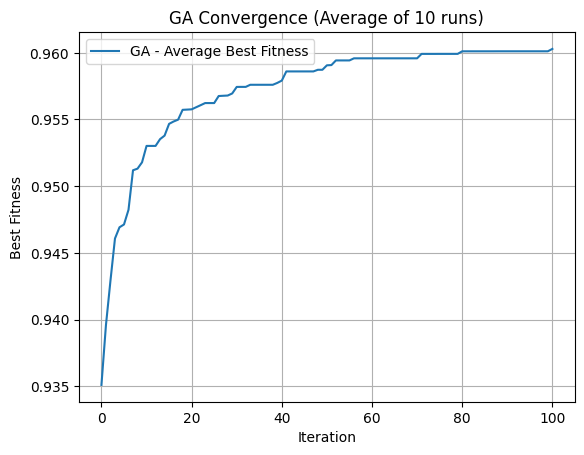

In [36]:
ga_avg_hist = np.mean(ga_histories, axis=0)

plt.figure()
plt.plot(ga_avg_hist, label='GA - Average Best Fitness')
plt.title('GA Convergence (Average of 10 runs)')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.legend()
plt.savefig('ga_convergence.png')
plt.show()


In [23]:
def simulated_annealing(n_features=30, seed=None, noise_std=0.0):
    if seed is not None:
        np.random.seed(seed)
    
    INITIAL_TEMP = 100.0
    COOLING_RATE = 0.995
    MIN_TEMP = 0.001
    
    current = np.random.randint(0, 2, n_features)
    current_fitness = evaluate_features(current, noise_std=noise_std)
    
    best = current.copy()
    best_fitness = current_fitness
    
    temperature = INITIAL_TEMP
    history = [best_fitness]
    
    eval_count = 1  # ارزیابی اولیه
    MAX_EVAL = 4500
    
    while temperature > MIN_TEMP and eval_count < MAX_EVAL:
        flips = min(10, MAX_EVAL - eval_count)  # تعداد flip در این دما
        
        for _ in range(flips):
            neigh = current.copy()
            flip_idx = np.random.randint(0, n_features)
            neigh[flip_idx] = 1 - neigh[flip_idx]
            
            new_fitness = evaluate_features(neigh, noise_std=noise_std)
            eval_count += 1
            
            delta = new_fitness - current_fitness
            
            if delta > 0 or np.random.rand() < np.exp(delta / temperature):
                current = neigh
                current_fitness = new_fitness
                
                if current_fitness > best_fitness:
                    best = current.copy()
                    best_fitness = current_fitness
            
            history.append(best_fitness)
            
            if eval_count >= MAX_EVAL:
                break
        
        temperature *= COOLING_RATE
    
    return best, best_fitness, history

In [24]:
start = time.time()
best_mask, best_score, history = simulated_annealing(noise_std=0.05)
end = time.time()

print("بهترین fitness:", best_score)
print("تعداد ویژگی:", best_mask.sum())
print("زمان:", round(end - start, 1), "ثانیه")

بهترین fitness: 0.9441950007762768
تعداد ویژگی: 12
زمان: 37.5 ثانیه


In [25]:
# ۱۰ ران SA بگیر و خلاصه نتایج رو چاپ کن
results = []
times = []
sa_histories = []

for run in range(10):
    seed = 42 + run
    start = time.time()
    best_mask, best_score, history = simulated_annealing(seed=seed, noise_std=0.05)
    elapsed = time.time() - start
    
    results.append((best_score, best_mask.sum()))
    times.append(elapsed)
    sa_histories.append(history)
    
    print(f"Run {run+1}: fitness={best_score:.4f}, features={best_mask.sum()}, time={elapsed:.1f}s")

fitness_vals = [r[0] for r in results]
feat_counts = [r[1] for r in results]

print("\n--- خلاصه SA ---")
print("میانگین fitness:", np.mean(fitness_vals))
print("انحراف معیار fitness:", np.std(fitness_vals))
print("میانگین تعداد ویژگی:", np.mean(feat_counts))
print("میانگین زمان هر ران:", np.mean(times), "ثانیه")

Run 1: fitness=0.9436, features=9, time=37.6s
Run 2: fitness=0.9440, features=11, time=37.4s
Run 3: fitness=0.9521, features=7, time=37.3s
Run 4: fitness=0.9438, features=10, time=37.3s
Run 5: fitness=0.9491, features=10, time=36.8s
Run 6: fitness=0.9489, features=9, time=36.8s
Run 7: fitness=0.9521, features=7, time=37.6s
Run 8: fitness=0.9470, features=8, time=37.3s
Run 9: fitness=0.9454, features=9, time=37.9s
Run 10: fitness=0.9452, features=8, time=38.3s

--- خلاصه SA ---
میانگین fitness: 0.9471315013196708
انحراف معیار fitness: 0.003085290838355204
میانگین تعداد ویژگی: 8.8
میانگین زمان هر ران: 37.43471508026123 ثانیه


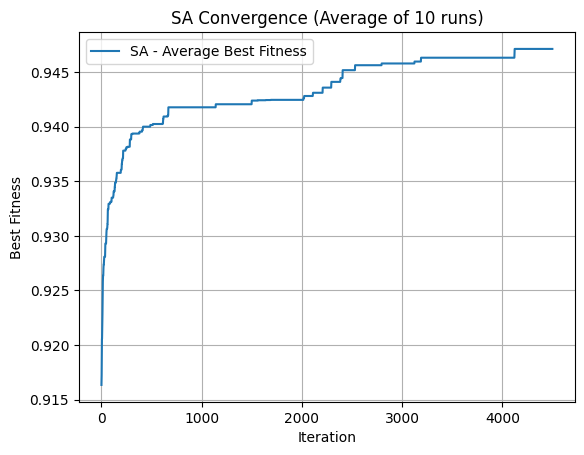

In [26]:
# فرض: histories لیست ۱۰ تا history از ۱۰ ران SA هست
# اگر هنوز histories رو نداری، باید توی حلقه ۱۰ ران ذخیره‌شون کنی

# میانگین همگرایی در هر مرحله
sa_avg_hist = np.mean(sa_histories, axis=0)

plt.figure()
plt.plot(sa_avg_hist, label='SA - Average Best Fitness')
plt.title('SA Convergence (Average of 10 runs)')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.legend()
plt.savefig('sa_convergence.png')
plt.show()

In [27]:
def binary_pso(n_features=30, seed=None, noise_std=0.0):
    if seed is not None:
        np.random.seed(seed)
    
    N_PARTICLES = 40
    MAX_ITER = 112     # ≈4500 ارزیابی
    
    position = np.random.randint(0, 2, (N_PARTICLES, n_features))
    velocity = np.random.uniform(-1, 1, (N_PARTICLES, n_features))
    
    pbest_pos = position.copy()
    pbest_fit = np.array([evaluate_features(p, noise_std=noise_std) for p in pbest_pos])
    
    gbest_idx = np.argmax(pbest_fit)
    gbest_pos = pbest_pos[gbest_idx].copy()
    gbest_fit = pbest_fit[gbest_idx]
    
    history = [gbest_fit]
    
    for it in range(MAX_ITER):
        for i in range(N_PARTICLES):
            r1 = np.random.rand(n_features)
            r2 = np.random.rand(n_features)
            
            velocity[i] = (0.7 * velocity[i] +
                           1.4 * r1 * (pbest_pos[i] - position[i]) +
                           1.5 * r2 * (gbest_pos - position[i]))
            
            sig = 1 / (1 + np.exp(-velocity[i]))
            position[i] = (np.random.rand(n_features) < sig).astype(int)
            
            fit = evaluate_features(position[i], noise_std=noise_std)
            
            if fit > pbest_fit[i]:
                pbest_fit[i] = fit
                pbest_pos[i] = position[i].copy()
                
                if fit > gbest_fit:
                    gbest_fit = fit
                    gbest_pos = position[i].copy()
        
        history.append(gbest_fit)
    
    return gbest_pos, gbest_fit, history

In [28]:
start = time.time()
best_mask, best_score, history = binary_pso(seed=42, noise_std=0.05)
end = time.time()

print("بهترین fitness:", best_score)
print("تعداد ویژگی:", best_mask.sum())
print("زمان:", round(end - start, 1), "ثانیه")

بهترین fitness: 0.9541950007762768
تعداد ویژگی: 9
زمان: 36.6 ثانیه


In [29]:
results = []
times = []
pso_histories = []

for run in range(10):
    seed = 42 + run
    start = time.time()
    best_mask, best_score, history = binary_pso(seed=seed, noise_std=0.05)
    elapsed = time.time() - start
    
    results.append((best_score, best_mask.sum()))
    times.append(elapsed)
    pso_histories.append(history)
    
    print(f"Run {run+1}: fitness={best_score:.4f}, features={best_mask.sum()}, time={elapsed:.1f}s")

fitness_vals = [r[0] for r in results]
feat_counts = [r[1] for r in results]

print("\n--- خلاصه PSO ---")
print("میانگین fitness:", np.mean(fitness_vals))
print("انحراف معیار fitness:", np.std(fitness_vals))
print("میانگین تعداد ویژگی:", np.mean(feat_counts))
print("میانگین زمان:", np.mean(times), "ثانیه")

Run 1: fitness=0.9542, features=9, time=36.5s
Run 2: fitness=0.9570, features=5, time=36.5s
Run 3: fitness=0.9538, features=7, time=36.0s
Run 4: fitness=0.9535, features=5, time=36.5s
Run 5: fitness=0.9524, features=9, time=36.5s
Run 6: fitness=0.9537, features=6, time=36.5s
Run 7: fitness=0.9571, features=6, time=36.4s
Run 8: fitness=0.9554, features=6, time=36.4s
Run 9: fitness=0.9558, features=8, time=36.8s
Run 10: fitness=0.9587, features=5, time=36.4s

--- خلاصه PSO ---
میانگین fitness: 0.9551681415929203
انحراف معیار fitness: 0.001890677840231326
میانگین تعداد ویژگی: 6.6
میانگین زمان: 36.44671304225922 ثانیه


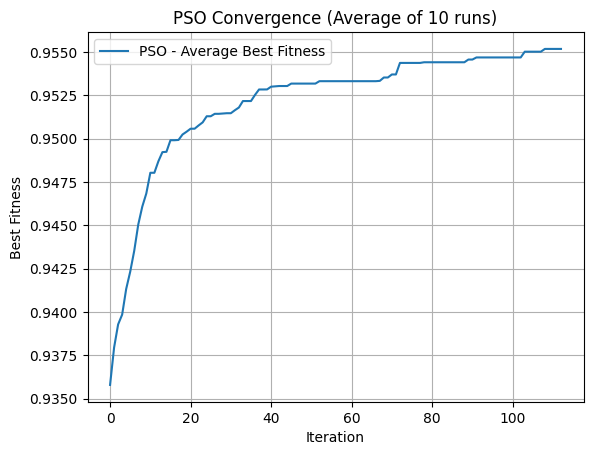

In [30]:
# histories از ۱۰ ران PSO رو داشته باش
pso_avg_hist = np.mean(pso_histories, axis=0)

plt.figure()
plt.plot(pso_avg_hist, label='PSO - Average Best Fitness')
plt.title('PSO Convergence (Average of 10 runs)')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.legend()
plt.savefig('pso_convergence.png')
plt.show()

In [31]:
def tabu_search(n_features=30, seed=None, noise_std=0.0):
    if seed is not None:
        np.random.seed(seed)
    
    TABU_TENURE = 10
    MAX_ITER = 900           # ≈4500 ارزیابی (با میانگین 5 همسایه)
    
    current = np.random.randint(0, 2, n_features)
    current_fitness = evaluate_features(current, noise_std=noise_std)
    
    best = current.copy()
    best_fitness = current_fitness
    
    tabu_list = deque(maxlen=TABU_TENURE)
    
    history = [best_fitness]
    
    for _ in range(MAX_ITER):
        best_neigh = None
        best_neigh_fit = -np.inf
        best_flip_idx = -1
        
        for i in range(n_features):
            if i in tabu_list:
                continue
            neigh = current.copy()
            neigh[i] = 1 - neigh[i]
            fit = evaluate_features(neigh, noise_std=noise_std)
            
            if fit > best_neigh_fit:
                best_neigh_fit = fit
                best_neigh = neigh.copy()
                best_flip_idx = i
        
        if best_neigh is None:
            continue
        
        current = best_neigh
        current_fitness = best_neigh_fit
        
        if current_fitness > best_fitness:
            best = current.copy()
            best_fitness = current_fitness
        
        tabu_list.append(best_flip_idx)
        history.append(best_fitness)
    
    return best, best_fitness, history

In [32]:
start = time.time()
best_mask, best_score, history = tabu_search(seed=42, noise_std=0.05)
end = time.time()

print("بهترین fitness:", best_score)
print("تعداد ویژگی:", best_mask.sum())
print("زمان:", round(end - start, 1), "ثانیه")

بهترین fitness: 0.9606862288464524
تعداد ویژگی: 6
زمان: 139.4 ثانیه


In [33]:
results = []
times = []
tb_histories = []

for run in range(10):
    seed = 42 + run
    start = time.time()
    best_mask, best_score, history = tabu_search(seed=seed, noise_std=0.05)
    elapsed = time.time() - start
    
    results.append((best_score, best_mask.sum()))
    times.append(elapsed)
    tb_histories.append(history)
    
    print(f"Run {run+1}: fitness={best_score:.4f}, features={best_mask.sum()}, time={elapsed:.1f}s")

fitness_vals = [r[0] for r in results]
feat_counts = [r[1] for r in results]

print("\n--- خلاصه tabu search ---")
print("میانگین fitness:", np.mean(fitness_vals))
print("انحراف معیار fitness:", np.std(fitness_vals))
print("میانگین تعداد ویژگی:", np.mean(feat_counts))
print("میانگین زمان:", np.mean(times), "ثانیه")

Run 1: fitness=0.9607, features=6, time=141.4s
Run 2: fitness=0.9607, features=6, time=141.2s
Run 3: fitness=0.9638, features=4, time=141.6s
Run 4: fitness=0.9621, features=4, time=141.7s
Run 5: fitness=0.9638, features=4, time=140.9s
Run 6: fitness=0.9638, features=4, time=141.1s
Run 7: fitness=0.9623, features=5, time=141.3s
Run 8: fitness=0.9607, features=6, time=140.8s
Run 9: fitness=0.9642, features=6, time=141.1s
Run 10: fitness=0.9622, features=5, time=141.2s

--- خلاصه tabu search ---
میانگین fitness: 0.9624281943797548
انحراف معیار fitness: 0.001356322896764365
میانگین تعداد ویژگی: 5.0
میانگین زمان: 141.2388947725296 ثانیه


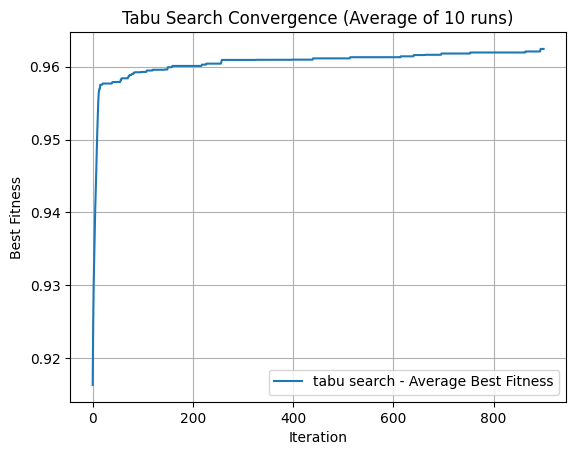

In [34]:
ts_avg_hist = np.mean(tb_histories, axis=0)

plt.figure()
plt.plot(ts_avg_hist, label='tabu search - Average Best Fitness')
plt.title('Tabu Search Convergence (Average of 10 runs)')
plt.xlabel('Iteration')
plt.ylabel('Best Fitness')
plt.grid(True)
plt.legend()
plt.savefig('TabuSeach_convergence.png')
plt.show()

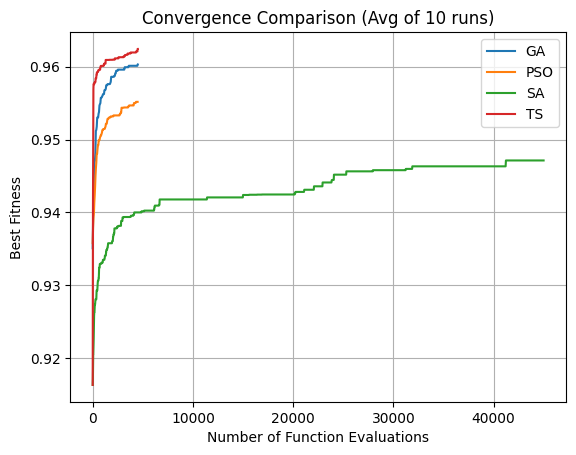

In [35]:
eval_per_step = {
    'GA': 45,
    'PSO': 40,
    'SA': 10,
    'TS': 5
}
x_ga  = np.arange(len(ga_avg_hist))  * eval_per_step['GA']
x_pso = np.arange(len(pso_avg_hist)) * eval_per_step['PSO']
x_sa  = np.arange(len(sa_avg_hist))  * eval_per_step['SA']
x_ts  = np.arange(len(ts_avg_hist))  * eval_per_step['TS']

plt.figure()
plt.plot(x_ga,  ga_avg_hist,  label='GA')
plt.plot(x_pso, pso_avg_hist, label='PSO')
plt.plot(x_sa,  sa_avg_hist,  label='SA')
plt.plot(x_ts,  ts_avg_hist,  label='TS')
plt.title('Convergence Comparison (Avg of 10 runs)')
plt.xlabel('Number of Function Evaluations')
plt.ylabel('Best Fitness')
plt.legend()
plt.grid(True)
plt.savefig('convergence_vs_evaluations.png')
plt.show()